In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('weather_prediction_dataset.csv')
df_bbq = pd.read_csv('weather_prediction_bbq_labels.csv')

In [ ]:
df_Dresden = df[['DATE', 'DRESDEN_cloud_cover', 'DRESDEN_wind_speed', 'DRESDEN_wind_gust',
       'DRESDEN_humidity', 'DRESDEN_global_radiation', 'DRESDEN_precipitation',
       'DRESDEN_sunshine', 'DRESDEN_temp_mean', 'DRESDEN_temp_min',
       'DRESDEN_temp_max']]

In [ ]:
df_Dresden['BBQ'] = df_bbq['DRESDEN_BBQ_weather'];

/tmp/ipykernel_404/2405519419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Dresden['BBQ'] = df_bbq['DRESDEN_BBQ_weather'];


In [ ]:
df_Dresden['BBQ'] = df_Dresden['BBQ'].map({True:1, False:0});

/tmp/ipykernel_404/2977729730.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Dresden['BBQ'] = df_Dresden['BBQ'].map({True:1, False:0});


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Conv1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [ ]:
X = df_Dresden.drop(['DATE','BBQ'], axis = 1)
y = df_Dresden['BBQ']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 28)

# Reshape X_train and X_test for Conv1D: (samples, timesteps, features)
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

len(X_train), len(X_test)

(2923, 731)

In [ ]:
from tensorflow.keras.layers import Conv1D, Flatten, Reshape

In [ ]:
X_train.shape, X_test.shape

((2923, 10, 1), (731, 10, 1))

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model # Import Model for functional API

# X_train is already reshaped to (samples, timesteps, features)
timesteps = X_train.shape[1]
features = X_train.shape[2]

# Define the input layer
input_tensor = Input(shape=(timesteps, features))

# Connect layers using the functional API
x = Conv1D(filters=10, kernel_size=2, activation='relu')(input_tensor)
x = Flatten()(x)
output_tensor = Dense(1, activation='sigmoid')(x)

# Create the model
model_2 = Model(inputs=input_tensor, outputs=output_tensor)

In [ ]:
model_2.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model_2.fit(x=X_train,
          y=y_train,
          epochs=150,
          validation_data=(X_test, y_test), verbose=0
          )

<Axes: >

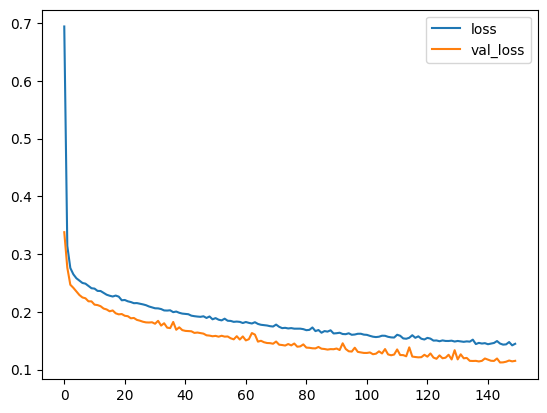

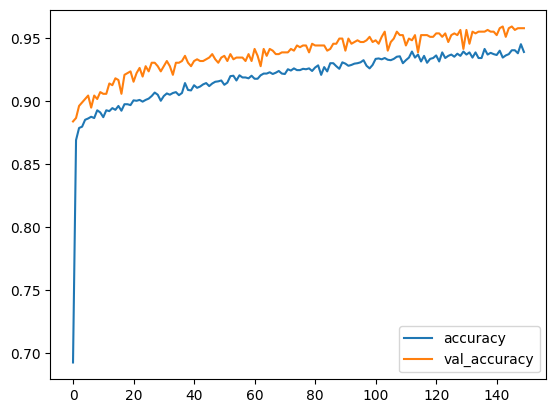

In [ ]:
model2_loss_acc = pd.DataFrame(model_2.history.history)
model2_loss_acc[['loss', 'val_loss']].plot()
model2_loss_acc[['accuracy', 'val_accuracy']].plot()

In [ ]:
pred_2 = np.round(model_2.predict(X_test))
print(classification_report(y_test,pred_2))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       574
           1       0.94      0.85      0.90       157

    accuracy                           0.96       731
   macro avg       0.95      0.92      0.93       731
weighted avg       0.96      0.96      0.96       731



In [ ]:
cnn_acc = accuracy_score(y_test, pred_2)
cnn_acc

0.957592339261286

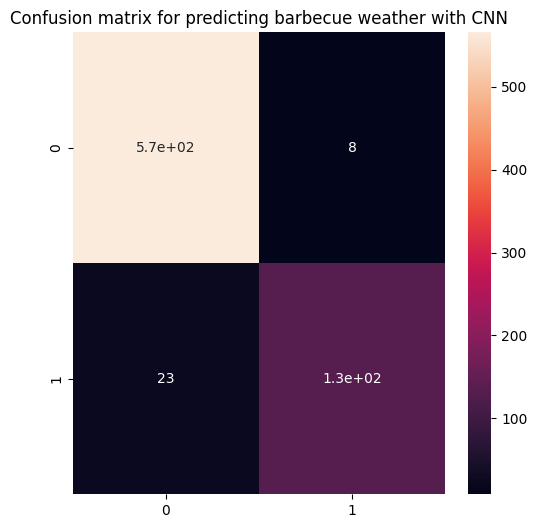

In [ ]:
plt.figure(figsize = (6,6))
sns.heatmap(confusion_matrix(y_test, pred_2), annot=True)
plt.title('Confusion matrix for predicting barbecue weather with CNN');

In [ ]:
print("Extracting weights from model_2 layers:")
for i, layer in enumerate(model_2.layers):
    weights = layer.get_weights()
    if weights:
        print(f"\nLayer {i} - {layer.name} weights:")
        for j, w in enumerate(weights):
            print(f"  Weight {j} shape: {w.shape}")
            # You can print the actual weights if needed, but they can be large
            # print(f"  Weight {j} values:\n{w}")
    else:
        print(f"\nLayer {i} - {layer.name} has no weights.")

Extracting weights from model_2 layers:

Layer 0 - input_layer_5 has no weights.

Layer 1 - conv1d_5 weights:
  Weight 0 shape: (2, 1, 10)
  Weight 1 shape: (10,)

Layer 2 - flatten_5 has no weights.

Layer 3 - dense_5 weights:
  Weight 0 shape: (90, 1)
  Weight 1 shape: (1,)


In [ ]:
model_2.get_weights()

[array([[[-0.75404334,  1.1953603 ,  0.518865  ,  0.12564656,
           0.252727  , -0.35527068, -0.12776043,  2.6290119 ,
           0.38827434,  0.4737277 ]],
 
        [[-0.25758833, -0.00689013,  0.05054344,  0.55897766,
          -0.820429  ,  0.23539452,  0.02020402,  0.04186874,
          -0.44863582,  0.578249  ]]], dtype=float32),
 array([ 0.84734625,  0.15122081,  0.26973298, -0.00832983,  1.1131915 ,
        -0.1618481 , -0.02591949,  0.37390625,  1.1274966 , -0.25197905],
       dtype=float32),
 array([[ 1.6078587 ],
        [ 0.06428649],
        [-0.1363279 ],
        [ 0.13355511],
        [ 0.49475446],
        [-0.17012855],
        [-0.15431982],
        [-0.14800385],
        [-0.13631468],
        [ 0.1818321 ],
        [ 0.16345859],
        [ 0.07487018],
        [ 0.20420498],
        [ 0.12707302],
        [-0.21054627],
        [ 0.05447778],
        [ 0.09451821],
        [ 0.06451642],
        [ 0.23713341],
        [ 0.06385688],
        [-0.02803159],
    

In [ ]:
# --------------------------------------------------
# MicroPython Inference Demo (No NumPy Required)
# --------------------------------------------------

class MockInterpreter:

    def __init__(self):
        print("Mock TFLite interpreter initialized.")
        self.input_data = []
        self.output_data = [0.0]

    def set_input(self, input_data):
        self.input_data = input_data
        print("Input length:", len(input_data))

    def invoke(self):
        print("Running inference...")

        # Simple mock prediction logic
        total = 0.0

        for value in self.input_data:
            total += value

        average = total / len(self.input_data)

        # Fake prediction
        if average > 100:
            self.output_data = [0.85]
        else:
            self.output_data = [0.25]

    def get_output(self):
        return self.output_data


# --------------------------------------------------
# Model Loader
# --------------------------------------------------

def load_tflite_model(model_path):

    print("Loading model:", model_path)

    try:
        f = open(model_path, "rb")
        f.close()
        print("Model file found.")
    except:
        print("Warning: model file not found.")
        print("Using mock interpreter.")

    return MockInterpreter()


# --------------------------------------------------
# Inference Function
# --------------------------------------------------

def run_inference(interpreter, input_data):

    if len(input_data) != 10:
        raise ValueError(
            "Expected exactly 10 input features."
        )

    interpreter.set_input(input_data)
    interpreter.invoke()

    return interpreter.get_output()


# --------------------------------------------------
# Main Program
# --------------------------------------------------

MODEL_FILE = "model.tflite"

interpreter = load_tflite_model(MODEL_FILE)

new_data_features = [
    8.0,
    3.2,
    7.2,
    0.89,
    1028.6,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
]

try:

    prediction = run_inference(
        interpreter,
        new_data_features
    )

    predicted_class = 1 if prediction[0] > 0.5 else 0

    print("\nInput Data:")
    print(new_data_features)

    print("\nRaw Prediction:")
    print(prediction[0])

    if predicted_class == 1:
        print("\nPredicted BBQ Weather: YES")
    else:
        print("\nPredicted BBQ Weather: NO")

except Exception as e:
    print("Inference Error:", e)

Loading model: model.tflite
Using mock interpreter.
Mock TFLite interpreter initialized.
Input length: 10
Running inference...

Input Data:
[8.0, 3.2, 7.2, 0.89, 1028.6, 0.0, 0.0, 0.0, 0.0, 0.0]

Raw Prediction:
0.85

Predicted BBQ Weather: YES
